In [1]:
# Install the needed dependeincies
# !pip install requests numpy polars pandas

# Example plots


Load the needed libraries

In [2]:
import re
import subprocess
from datetime import datetime, timedelta
from pathlib import Path

import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# general settings for polars
pl.Config.set_tbl_cols(1000)
pl.Config.set_tbl_width_chars(1000)

polars.config.Config

In [3]:
# ---- Constants
BACKENDS = ["POSIX", "MPIIO"]
SCENARIOS=(
	"write_seq_4k",
	"read_seq_4k",
	"write_seq_4m",
	"read_seq_4m",
	"write_rand_4k",
	"read_rand_4k",
	"writeread_rand_4k_shared",
)
NITER = 10
SLURM_JOB_ID_SCRATCH = "955566"

# offset to apply before the first timestamp and after the last timestamp performing the query,
#  needed in plots
OFFSET_IN_SECONDS = 60 
BUCKET_S = 1     # plotting only... clusterize allthe point in buckets of this size (in seconds), center to the middle of the bucket. (needed for aggregation)

In [4]:
# --- CONSTANTS
PRJ_ROOT_DIR = Path(
    subprocess.check_output(
        ["git", "rev-parse", "--show-toplevel"],
        text=True
    ).strip()
)
DATA_DIR = Path(PRJ_ROOT_DIR, "data")
IOR_RESULTS_DIR = PRJ_ROOT_DIR / "03-ior-bench" / "results" / "GENOA" / "scratch"

# print(f"Project root directory: {PRJ_ROOT_DIR}")
# print(f"Data directory: {DATA_DIR}")
# print(f"Ior results directory: {IOR_RESULTS_DIR}")

### Load the experiments table 

We are going to use it as a support table to simplify analysis

In [5]:
experiment_timetable = pl.read_parquet(DATA_DIR / "experiments" / "experiments.parquet")
experiment_timetable = experiment_timetable.filter(pl.col("SLURM_JOB_ID") == SLURM_JOB_ID_SCRATCH)
# experiment_timetable = experiment_timetable.filter(pl.col("SLURM_JOB_ID") == SLURM_JOB_ID_FAST)
experiment_timetable = experiment_timetable.select(["timestamp", "status", "notes"])
host_nodes = ("genoa007", "genoa008")

# print(experiment_timetable)
# print(time_min)
# print(time_max)

Reshape the experiment table in a more easy-to-tract dictionary

In [6]:
#  ---- 1. Parse fields from timetable -----
parsed = (
    experiment_timetable
    .with_columns(
        pl.col("notes")
        .str.extract(r"backend=([^-]+)", 1)
        .str.to_uppercase()
        .alias("backend"),

        pl.col("notes")
        .str.extract(r"scenario=(.+)_([0-9]+)$", 1)
        .alias("scenario"),

        pl.col("notes")
        .str.extract(r"scenario=(.+)_([0-9]+)$", 2)
        .cast(pl.Int64)
        .alias("iter"),
    )
    .filter(
        pl.col("backend").is_not_null()
        & pl.col("scenario").is_not_null()
        & pl.col("iter").is_not_null()
    )
)


#  ----- 2. Reshape START / END into columns ------
runs = (
    parsed
    .pivot(
        values="timestamp",
        index=["backend", "scenario", "iter"],
        on="status",
        aggregate_function="first",
    )
    .rename({
        "START": "start",
        "END": "end",
    })
    .sort(["backend", "scenario", "iter"])
)


#  ------ 3. Build nested dictionary ------
timetables = {}

for backend in BACKENDS:
    timetables[backend] = {}

    for scenario in SCENARIOS:
        df = (
            runs
            .filter(
                (pl.col("backend") == backend)
                & (pl.col("scenario") == scenario)
            )
            .select(["iter", "start", "end"])
            .sort("iter")
        )

        if df.height > 0:
            timetables[backend][scenario] = df


# --- example for debug
# print(timetables["POSIX"]["write_seq_4k"])

### Load the data

In [7]:
# ----- Load the data from DATA_DIR
tables = ["ipmi_power","cpu","diskio","net","ipmi_sensor","turbostat","pdu_power"]
columns_to_keep = {
    "ipmi_power": ["timestamp", "host", "value", "unit", "psu_id"],
    "cpu": ["timestamp", "host", "core_id", "usage_user", "usage_system", "usage_iowait", "usage_idle"],
    "diskio": ["timestamp", "host", "name", "merged_writes","reads","writes","read_bytes","write_bytes","read_time","write_time","merged_reads","io_time","weighted_io_time"],
    "net": ["timestamp", "host", "interface", "bytes_sent", "bytes_recv", "packets_sent", "packets_recv"],
    "ipmi_sensor": ["timestamp", "host", "name", "value"],
    "turbostat": ["host", "timestamp", "average_frequency_mhz", "busy_frequency_mhz", "core", "cpu", "core_temperature_celsius", "package", "package_temperature_celsius", "uncore_frequency_mhz"],
    "pdu_power": ["timestamp", "connected_device", "value_W"],
}

data = {}

In [8]:
def read_data_from_parquet(table_name, timefilter=None, column_names=None, data_dir=DATA_DIR):
    parquet_files = sorted((data_dir / table_name).glob("*.parquet"))

    if not parquet_files:
        print(f"No parquet files found for table {table_name} in {data_dir / table_name}")
        return pl.DataFrame()

    if timefilter is not None:
        time_min, time_max = timefilter

        selected_files = []
        for file in parquet_files:
            parts = file.stem.split("_")
            file_start = datetime.fromisoformat(parts[-2]).replace(tzinfo=time_min.tzinfo)
            file_end = datetime.fromisoformat(parts[-1]).replace(tzinfo=time_min.tzinfo)

            if file_start <= time_max and file_end >= time_min:
                selected_files.append(file)

        parquet_files = selected_files

    if not parquet_files:
        print(f"No parquet files overlap requested timerange for table {table_name}")
        return pl.DataFrame()

    dfs = []
    for file in parquet_files:
        try:
            df = pl.read_parquet(file)
            if column_names:
                df = df.select(column_names)
            

            dfs.append(df)
        except Exception as e:
            print(f"Error reading {file}: {e}")

    if not dfs:
        print(f"No valid parquet files found for table {table_name} in {data_dir / table_name}")
        return pl.DataFrame()

    df = pl.concat(dfs, how="vertical")

    # filter only for the ceph nodes
    host_prefix = "ceph"
    if "host" in df.columns:
        df = df.with_columns(
            pl.col("host").cast(pl.Utf8).str.strip_chars()
        ).filter(
            pl.col("host").str.starts_with(host_prefix)
        )
        
    if table_name == "ipmi_power":
        df = df.with_columns(
            [
                pl.col("unit").cast(pl.Utf8).str.strip_chars(),
                pl.col("host").cast(pl.Utf8).str.strip_chars(),
                pl.col("psu_id").cast(pl.Int64, strict=False),
            ]
        ).filter(
            (pl.col("unit") == "W") &
            (pl.col("psu_id") == 0)
        )

    if timefilter is not None:
        df = df.filter(pl.col("timestamp").is_between(timefilter[0], timefilter[1]))

    return df

In [9]:
for table in tables:
    data[table] = {}
    for backend in BACKENDS:
        # ---- Read only the plotted data
        if backend == "MPIIO":
            if backend not in timetables:
                continue
    
            data[table][backend] = {}
    
            for scenario in SCENARIOS:
         # ----- Read only the plotted data
                if scenario == "write_seq_4m":
                    if scenario not in timetables[backend]:
                        continue
        
                    time_min = (
                        timetables[backend][scenario]
                        .select(pl.col("start").min())[0, 0]
                        - timedelta(seconds=OFFSET_IN_SECONDS)
                    )
        
                    time_max = (
                        timetables[backend][scenario]
                        .select(pl.col("end").max())[0, 0]
                        + timedelta(seconds=OFFSET_IN_SECONDS)
                    )
        
                    data[table][backend][scenario] = read_data_from_parquet(
                        table,
                        column_names=columns_to_keep[table],
                        timefilter=[time_min, time_max],
                    )
        
                    # print(f"processed table {table} - scenario {scenario} - backend {backend}")

In [10]:
# data

### Plot the data

Some function definitions:

In [11]:
#  ------ Helper functions 
def _normalize_timestamp_column(df, col="timestamp"):
    if col not in df.columns:
        return df

    dtype = df.schema[col]
    dtype_str = str(dtype)

    if dtype_str in {"String", "Utf8"}:
        return df.with_columns(
            pl.col(col)
            .str.strptime(pl.Datetime, strict=False, exact=False)
            .dt.replace_time_zone("UTC")
            .alias(col)
        )

    if dtype_str.startswith("Datetime"):
        tz = getattr(dtype, "time_zone", None)
        if tz is None:
            return df.with_columns(
                pl.col(col).dt.replace_time_zone("UTC").alias(col)
            )
        return df.with_columns(
            pl.col(col).dt.convert_time_zone("UTC").alias(col)
        )

    return df

def limiter(ax, timetable, start=0, end=2, padding_seconds=30):
    if timetable is None or timetable.height == 0:
        return

    start_idx = min(start, timetable.height - 1)
    end_idx = min(max(end - 1, 0), timetable.height - 1)

    time_start = timetable.row(start_idx, named=True)["start"]
    time_end = timetable.row(end_idx, named=True)["end"]

    ax.set_xlim(
        time_start - timedelta(seconds=padding_seconds),
        time_end + timedelta(seconds=padding_seconds),
    )


def _add_iteration_markers(ax, timetable, color_start="#2ca02c", color_end="#d62728"):
    for i, row in enumerate(timetable.iter_rows(named=True)):
        start = row.get("start", row.get("Time-start"))
        end = row.get("end", row.get("Time-end"))

        ax.axvline(
            start,
            linestyle="--",
            linewidth=1.5,
            color=color_start,
            alpha=0.75,
            label="Iter Start" if i == 0 else None,
        )
        ax.axvline(
            end,
            linestyle="--",
            linewidth=1.5,
            color=color_end,
            alpha=0.75,
            label="Iter End" if i == 0 else None,
        )

In [12]:
def plot_power(data_pw, timetable, plt_title, savefig=False):
    bucket_every = f"{BUCKET_S}s"
    bucket_center_ms = int(BUCKET_S * 1000 / 2)

    pw_ts = _normalize_timestamp_column(data_pw, "timestamp")

    pw_agg = (
        pw_ts
        .sort("timestamp")
        .group_by_dynamic(
            "timestamp",
            every=bucket_every,
            period=bucket_every,
            closed="left",
            label="left",
        )
        .agg(
            pl.col("value").sum().alias("total_value")
        )
        .with_columns(
            (pl.col("timestamp") + pl.duration(milliseconds=bucket_center_ms)).alias("ts_center")
        )
        .sort("ts_center")
    )

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    color_power = "#0072B2"
    color_start = "#2ca02c"
    color_end = "#d62728"

    ax.plot(
        pw_agg["ts_center"].to_list(),
        pw_agg["total_value"].to_list(),
        linewidth=1.8,
        color=color_power,
        alpha=0.9,
        label="Aggregate value over hosts",
    )

    _add_iteration_markers(ax, timetable, color_start=color_start, color_end=color_end)
    limiter(ax, timetable)

    legend_handles = [
        Line2D([0], [0], color=color_power, linewidth=1.8, alpha=0.9, label="Aggregate value over hosts"),
        Line2D([0], [0], color=color_start, linestyle="--", linewidth=1.5, alpha=0.75, label="Start iteration"),
        Line2D([0], [0], color=color_end, linestyle="--", linewidth=1.5, alpha=0.75, label="End iteration"),
    ]

    ax.set_xlabel("Time", fontsize=10)
    ax.set_ylabel("Power [W]", fontsize=10)
    # ax.set_title(plt_title)

    ax.yaxis.grid(True, linestyle=":", alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", which="both", labelbottom=False, bottom=False)
    ax.legend(handles=legend_handles, loc="upper left", framealpha=0.9, edgecolor="lightgrey", fontsize=9)

    plt.tight_layout()

    if savefig:
        plt.savefig("img/power.pdf", bbox_inches="tight")

    plt.show()

In [13]:
def plot_cpu(data_cpu, timetable, plt_title, savefig=False):
    bucket_every = f"{BUCKET_S}s"
    bucket_center_ms = int(BUCKET_S * 1000 / 2)

    cpu_df = _normalize_timestamp_column(data_cpu, "timestamp")

    # Rebuild a synthetic host-level "cpu-total" row from per-core rows.
    # For CPU usage percentages, the correct host total is the mean across cores,
    # not the sum across cores.
    cpu_ts = (
        cpu_df
        .group_by(["host", "timestamp"])
        .agg([
            pl.col("usage_user").mean().alias("usage_user"),
            pl.col("usage_system").mean().alias("usage_system"),
            pl.col("usage_iowait").mean().alias("usage_iowait"),
        ])
        .sort("timestamp")
    )

    # Now aggregate across hosts inside each time bucket
    cpu_agg = (
        cpu_ts
        .sort("timestamp")
        .group_by_dynamic(
            "timestamp",
            every=bucket_every,
            period=bucket_every,
            closed="left",
            label="left",
        )
        .agg([
            pl.col("usage_user").sum().alias("usage_user"),
            pl.col("usage_system").sum().alias("usage_system"),
            pl.col("usage_iowait").sum().alias("usage_iowait"),
        ])
        .with_columns(
            (pl.col("timestamp") + pl.duration(milliseconds=bucket_center_ms)).alias("ts_center")
        )
        .sort("ts_center")
    )

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    ts = cpu_agg["ts_center"].to_list()

    color_user = "#0072B2"
    color_system = "#D55E00"
    color_iowait = "#009E73"

    ax.plot(
        ts,
        cpu_agg["usage_user"].to_list(),
        linewidth=1.0,
        color=color_user,
        alpha=0.9,
        label="CPU user",
    )
    ax.plot(
        ts,
        cpu_agg["usage_system"].to_list(),
        linewidth=1.0,
        color=color_system,
        alpha=0.9,
        label="CPU system",
    )
    ax.plot(
        ts,
        cpu_agg["usage_iowait"].to_list(),
        linewidth=1.0,
        color=color_iowait,
        alpha=0.9,
        label="CPU iowait",
    )

    _add_iteration_markers(ax, timetable)
    limiter(ax, timetable)

    ax.set_ylabel("CPU usage (sum across hosts)", fontsize=10)
    ax.set_xlabel("Time", fontsize=10)
    # ax.set_title(plt_title)

    ax.yaxis.grid(True, linestyle=":", alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", which="both", labelbottom=False, bottom=False)
    ax.legend(loc="upper left", framealpha=0.9, edgecolor="lightgrey", fontsize=9)

    plt.tight_layout()

    if savefig:
        plt.savefig("img/CPU.pdf", bbox_inches="tight")

    plt.show()

In [14]:
def plot_diskio(data_diskio, timetable, plt_title, bucket="1s", savefig=False):
    disk_ts = (
        _normalize_timestamp_column(data_diskio, "timestamp")
        .with_columns(
            pl.col("timestamp").dt.truncate(bucket).alias("ts")
        )
        .group_by("ts")
        .agg([
            pl.sum("read_bytes").alias("read_bytes"),
            pl.sum("write_bytes").alias("write_bytes"),
            pl.sum("reads").alias("reads"),
            pl.sum("writes").alias("writes"),
            pl.sum("merged_reads").alias("merged_reads"),
            pl.sum("merged_writes").alias("merged_writes"),
            pl.sum("read_time").alias("read_time"),
            pl.sum("write_time").alias("write_time"),
            pl.sum("io_time").alias("io_time"),
            pl.sum("weighted_io_time").alias("weighted_io_time"),
        ])
        .sort("ts")
    )

    disk_rate = (
        disk_ts
        .with_columns([
            pl.col("read_bytes").diff().clip(lower_bound=0).fill_null(0).alias("read_bytes_rate"),
            pl.col("write_bytes").diff().clip(lower_bound=0).fill_null(0).alias("write_bytes_rate"),
            pl.col("reads").diff().clip(lower_bound=0).fill_null(0).alias("reads_rate"),
            pl.col("writes").diff().clip(lower_bound=0).fill_null(0).alias("writes_rate"),
            pl.col("io_time").diff().clip(lower_bound=0).fill_null(0).alias("io_time_rate"),
            pl.col("read_time").diff().clip(lower_bound=0).fill_null(0).alias("read_time_rate"),
            pl.col("write_time").diff().clip(lower_bound=0).fill_null(0).alias("write_time_rate"),
            pl.col("weighted_io_time").diff().clip(lower_bound=0).fill_null(0).alias("weighted_io_time_rate"),
            pl.col("merged_reads").diff().clip(lower_bound=0).fill_null(0).alias("merged_reads_rate"),
            pl.col("merged_writes").diff().clip(lower_bound=0).fill_null(0).alias("merged_writes_rate"),
        ])
        .with_columns([
            (pl.col("read_bytes_rate") / (1024 * 1024)).alias("read_MBps"),
            (pl.col("write_bytes_rate") / (1024 * 1024)).alias("write_MBps"),
        ])
    )

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    color_read = "#0072B2"
    color_merged_read = "#56B4E9"
    color_write = "#D55E00"
    color_merged_write = "#E69F00"

    ax.plot(disk_rate["ts"].to_list(), disk_rate["reads_rate"].to_list(), linewidth=1.0, color=color_read, alpha=0.9, label="Read IOPS")
    ax.plot(disk_rate["ts"].to_list(), disk_rate["writes_rate"].to_list(), linewidth=1.0, color=color_write, alpha=0.9, label="Write IOPS")
    ax.plot(disk_rate["ts"].to_list(), disk_rate["merged_reads_rate"].to_list(), linestyle="--", linewidth=1.0, color=color_merged_read, alpha=0.9, label="Merged Read IOPS")
    ax.plot(disk_rate["ts"].to_list(), disk_rate["merged_writes_rate"].to_list(), linestyle="--", linewidth=1.0, color=color_merged_write, alpha=0.9, label="Merged Write IOPS")

    _add_iteration_markers(ax, timetable)
    limiter(ax, timetable)

    ax.set_ylabel("IOPS", fontsize=10)
    ax.set_xlabel("Time", fontsize=10)
    # ax.set_title(plt_title)

    ax.yaxis.grid(True, linestyle=":", alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", which="both", labelbottom=False, bottom=False)
    ax.legend(loc="upper left", ncol=2, framealpha=0.9, edgecolor="lightgrey", fontsize=8)

    plt.tight_layout()

    if savefig:
        plt.savefig("img/diskio.pdf", bbox_inches="tight")

    plt.show()

In [15]:
def plot_network(data_net, timetable, plt_title, bucket="1s", savefig=False):
    data_net = data_net.with_columns(
        pl.when(
            pl.col("interface").str.contains("ipo_ib|^ibp|^ipb")
        )
        .then(pl.lit("infiniband"))
        .otherwise(pl.col("interface"))
        .alias("iface_class")
    )

    net_ts = (
        _normalize_timestamp_column(data_net, "timestamp")
        .with_columns(
            pl.col("timestamp").dt.truncate(bucket).alias("ts")
        )
        .group_by(["ts", "iface_class"])
        .agg([
            pl.sum("bytes_sent").alias("bytes_sent"),
            pl.sum("bytes_recv").alias("bytes_recv"),
            pl.sum("packets_sent").alias("packets_sent"),
            pl.sum("packets_recv").alias("packets_recv"),
        ])
        .sort(["iface_class", "ts"])
    )

    net_rate = (
        net_ts
        .with_columns([
            pl.col("bytes_sent").diff().over("iface_class").clip(lower_bound=0).fill_null(0).alias("bytes_sent_rate"),
            pl.col("bytes_recv").diff().over("iface_class").clip(lower_bound=0).fill_null(0).alias("bytes_recv_rate"),
            pl.col("packets_sent").diff().over("iface_class").clip(lower_bound=0).fill_null(0).alias("packets_sent_rate"),
            pl.col("packets_recv").diff().over("iface_class").clip(lower_bound=0).fill_null(0).alias("packets_recv_rate"),
        ])
        .with_columns([
            (pl.col("bytes_sent_rate") / (1024 * 1024)).alias("sent_MBps"),
            (pl.col("bytes_recv_rate") / (1024 * 1024)).alias("recv_MBps"),
        ])
    )

    fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

    classes = sorted(net_rate["iface_class"].unique().to_list())
    palette = ["#0072B2", "#D55E00", "#009E73", "#CC79A7", "#E69F00", "#56B4E9"]

    for i, iface in enumerate(classes):
        iface_df = net_rate.filter(pl.col("iface_class") == iface)
        color = palette[i % len(palette)]

        ax.plot(
            iface_df["ts"].to_list(),
            iface_df["sent_MBps"].to_list(),
            linestyle="-",
            linewidth=1.0,
            color=color,
            alpha=0.9,
            label=f"{iface} TX",
        )
        # -- change color ot better distinguish
        if iface == "infiniband":
            color = "#009E73" # O
        ax.plot(
            iface_df["ts"].to_list(),
            iface_df["recv_MBps"].to_list(),
            linestyle="--",
            linewidth=1.0,
            color=color,
            alpha=0.9,
            label=f"{iface} RX",
        )

    _add_iteration_markers(ax, timetable)
    limiter(ax, timetable)

    ax.set_ylabel("Throughput (MB/s)", fontsize=10)
    ax.set_xlabel("Time", fontsize=10)
    # ax.set_title(plt_title)

    ax.yaxis.grid(True, linestyle=":", alpha=0.6)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", which="both", labelbottom=False, bottom=False)

    ncol = 2 if len(classes) > 1 else 1
    ax.legend(loc="upper left", ncol=ncol, framealpha=0.9, edgecolor="lightgrey", fontsize=8)

    plt.tight_layout()

    if savefig:
        plt.savefig("img/network.pdf", bbox_inches="tight")

    plt.show()

The actual plots

Plotting MPIIO - write_seq_4m


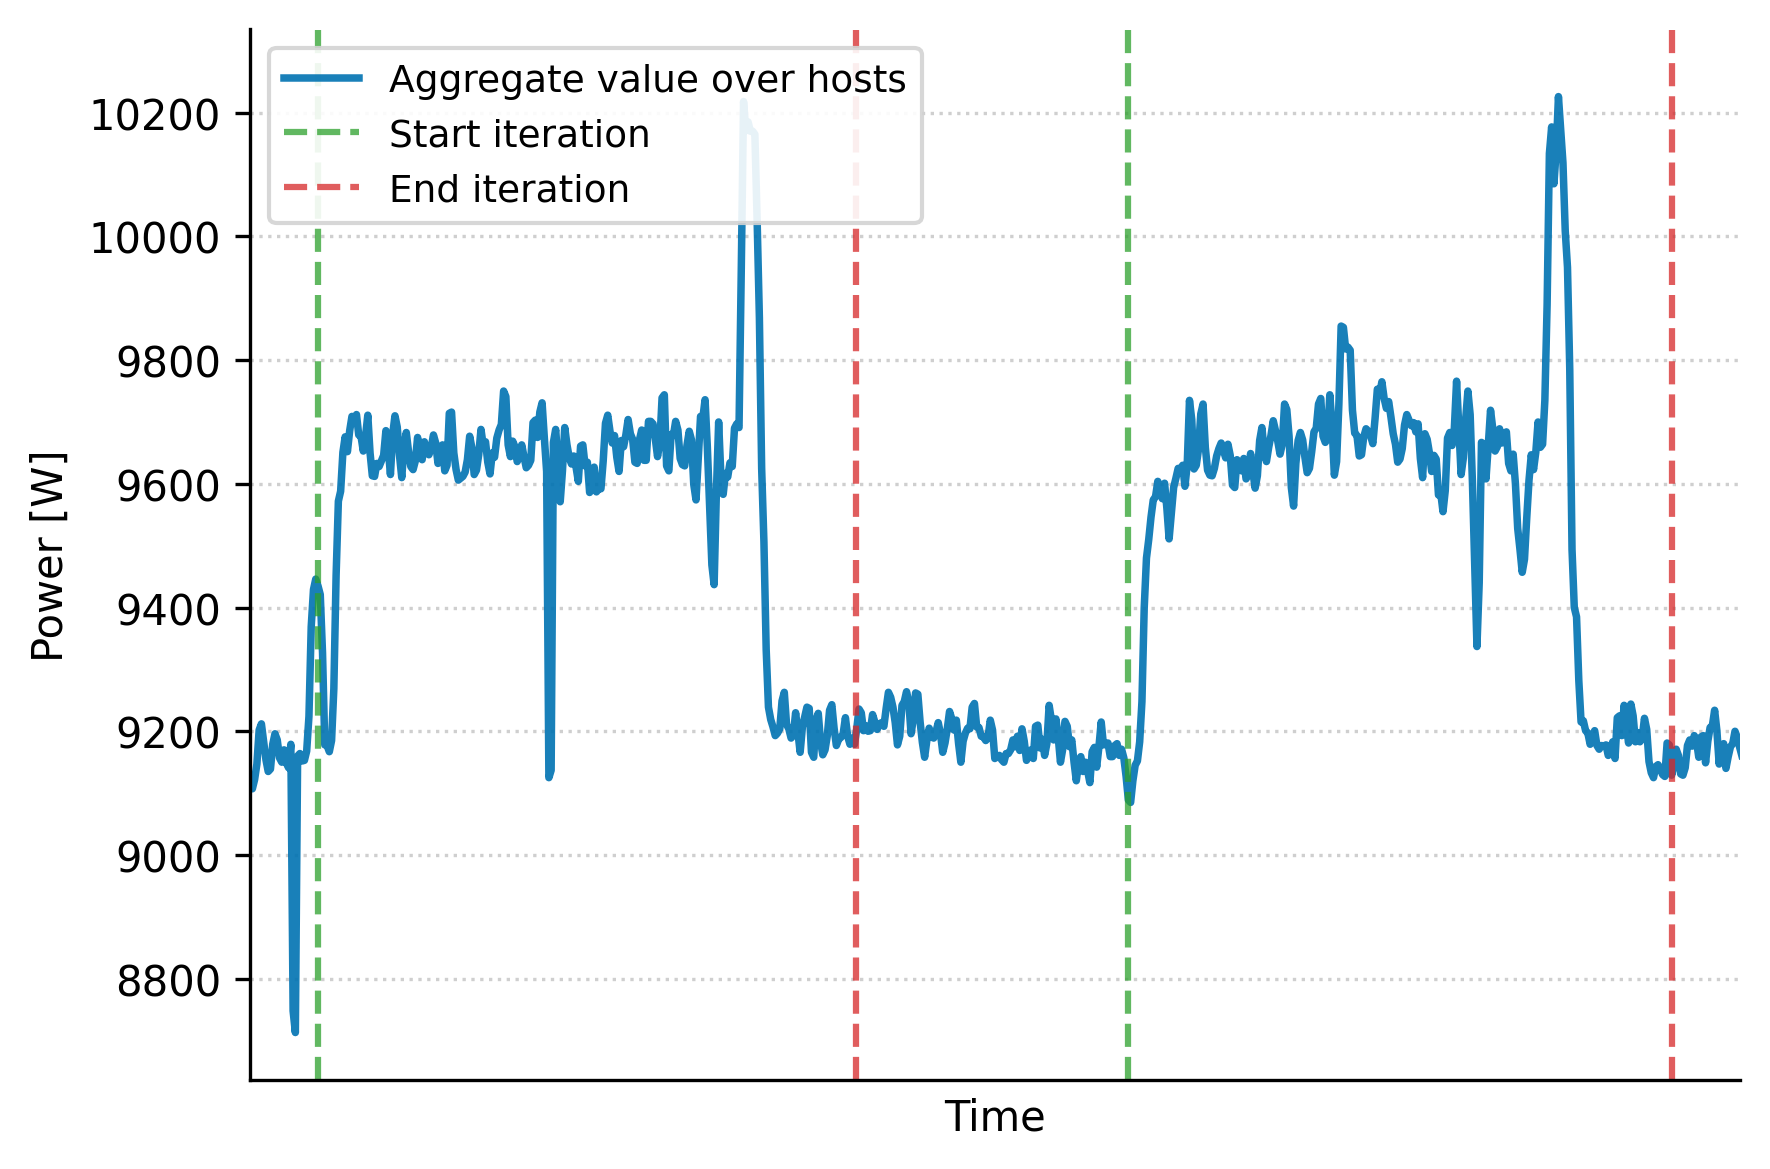

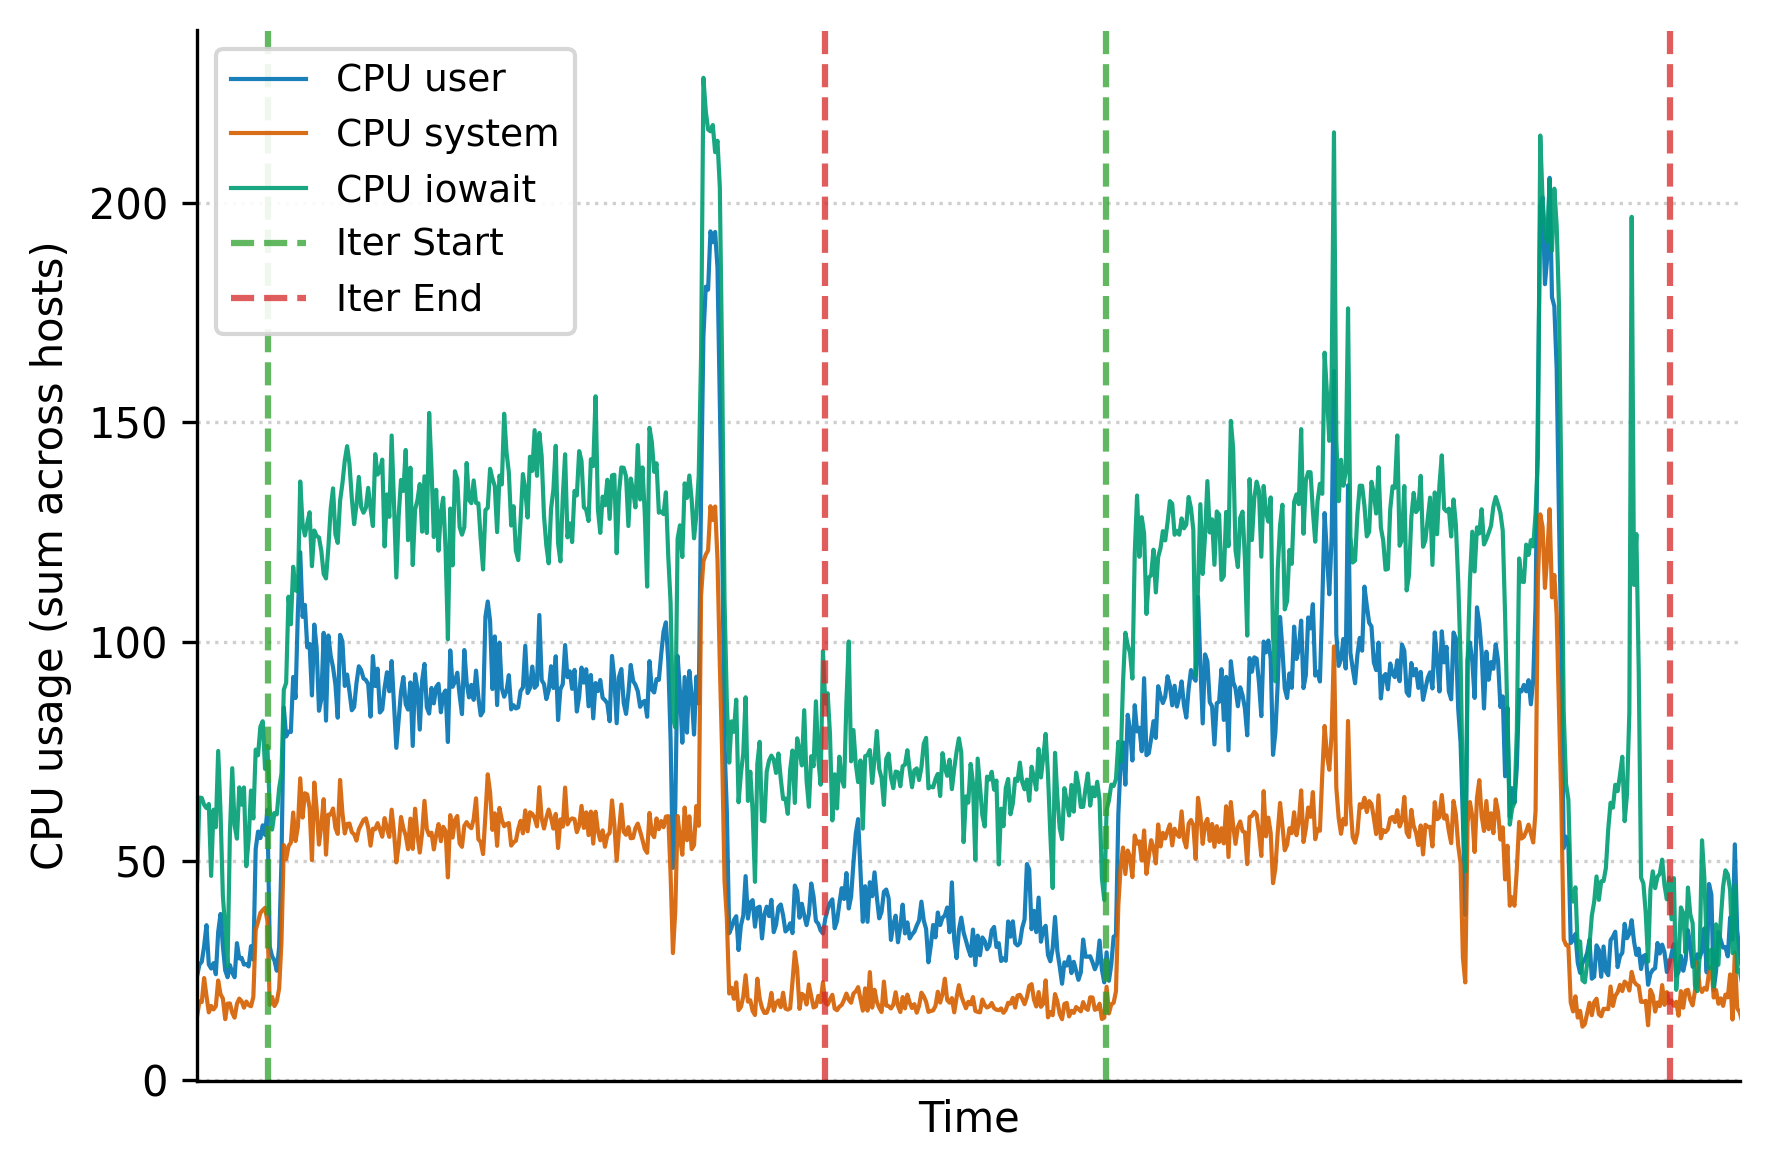

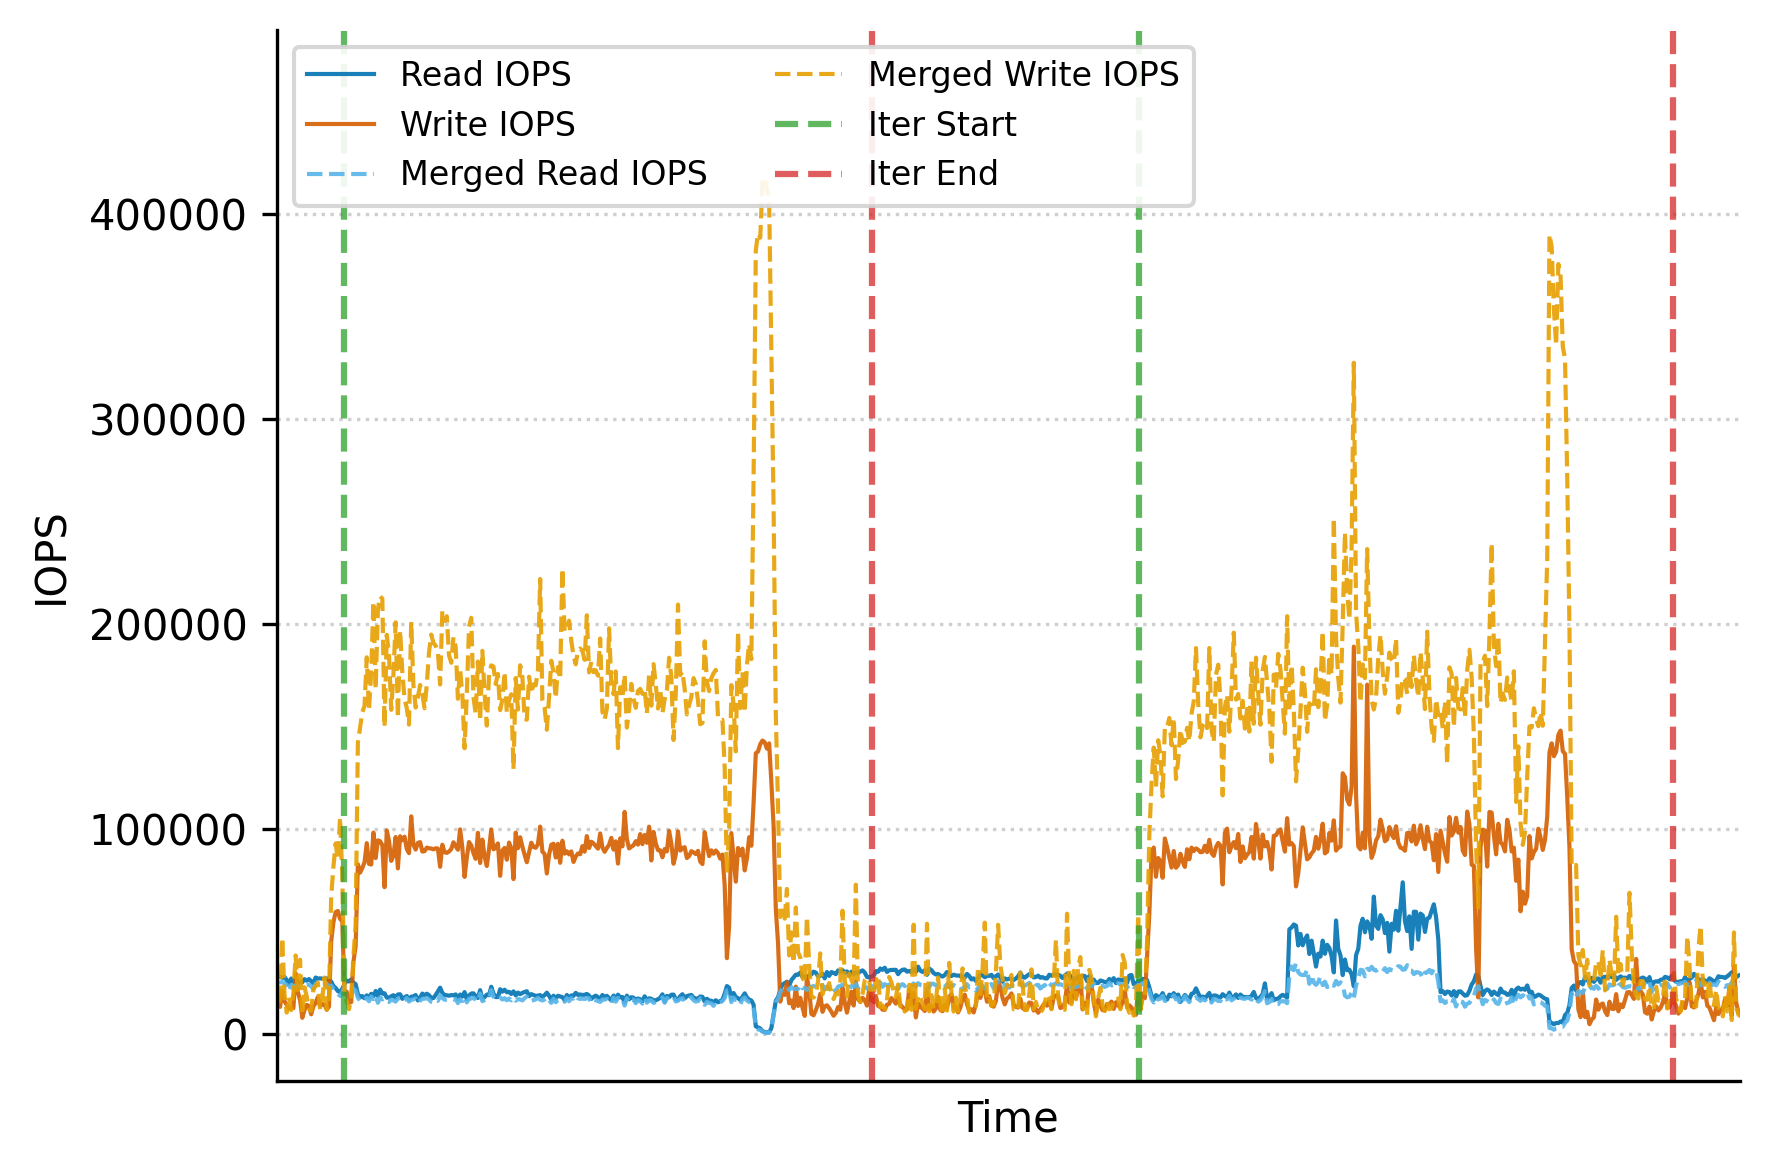

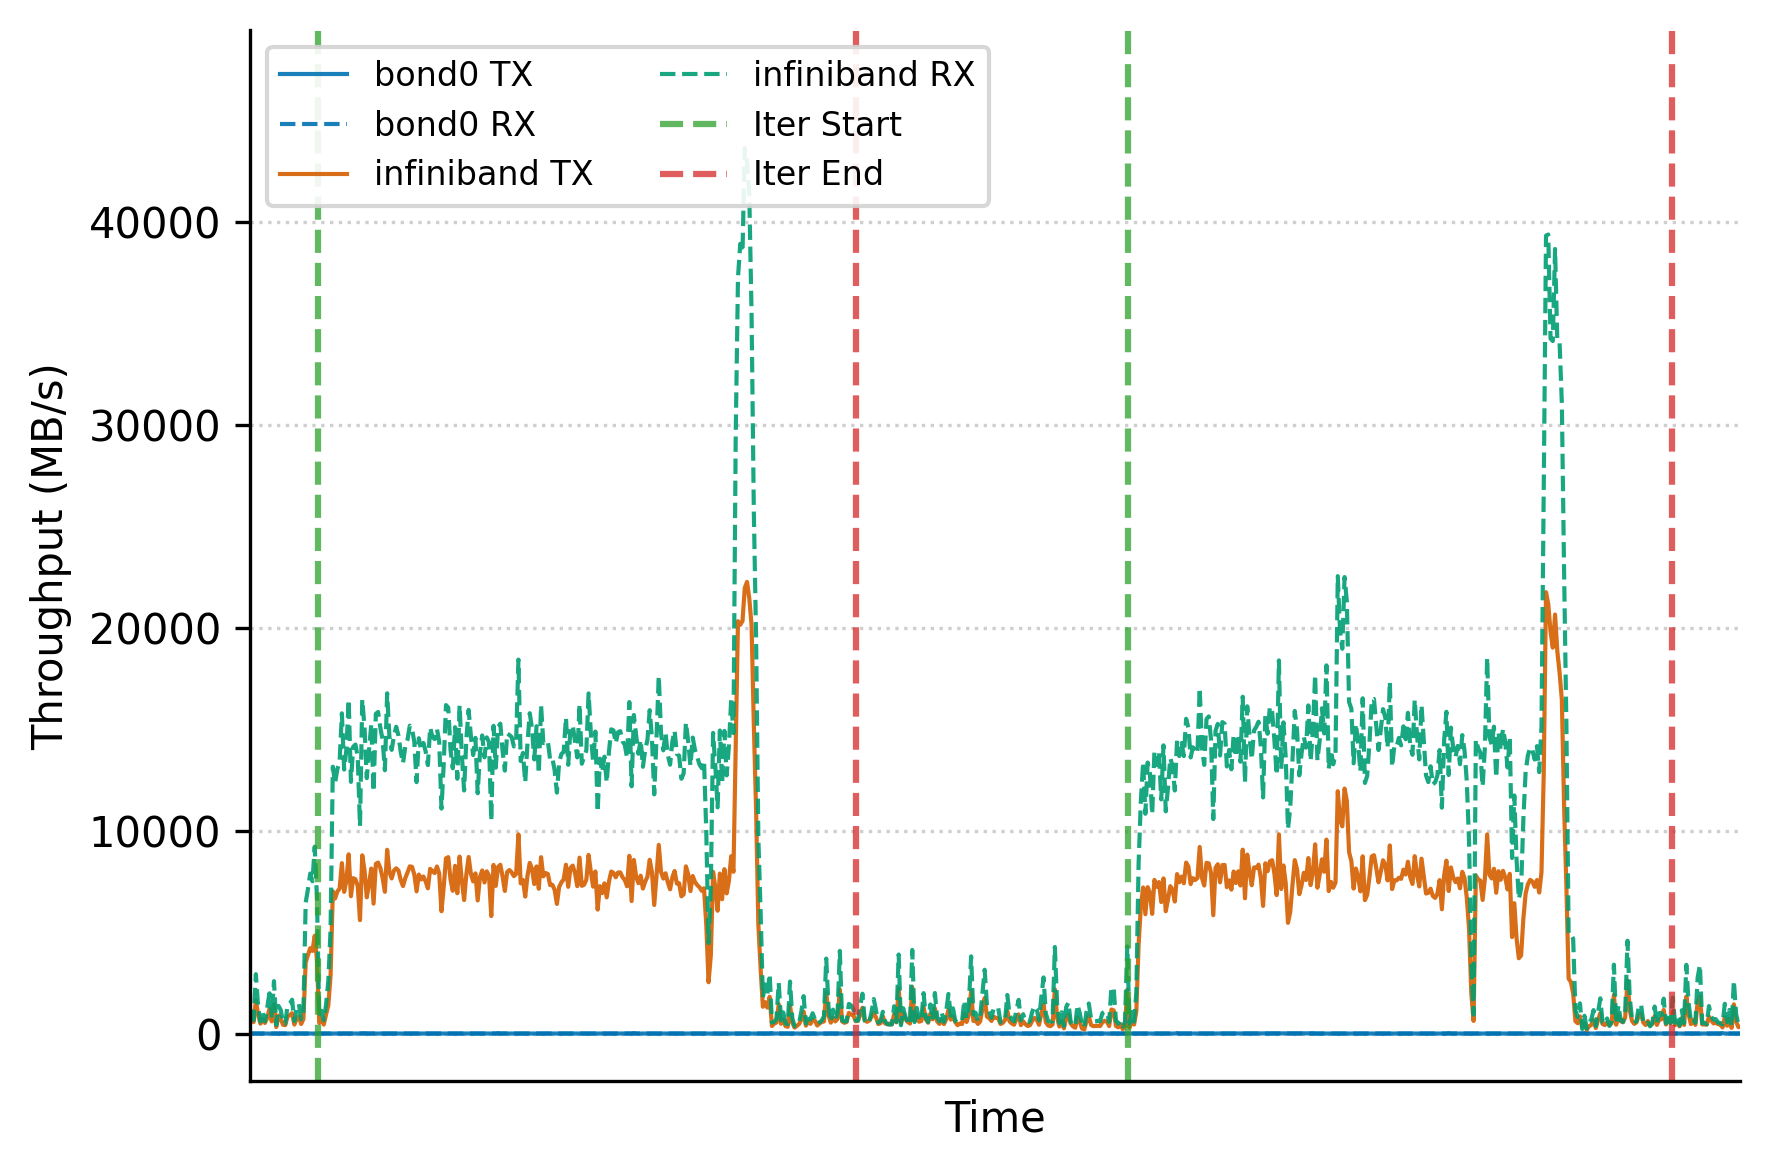

In [16]:
for backend in BACKENDS:
    for scenario in SCENARIOS:
        if scenario in timetables[backend]:
            if scenario == "write_seq_4m" and backend == "MPIIO":
                print(f"Plotting {backend} - {scenario}")
                plot_power(
                    data_pw=data["ipmi_power"][backend][scenario],
                    timetable=timetables[backend][scenario],
                    plt_title=f"{backend} - {scenario} situation",
                    savefig=False
                    )
                plot_cpu(
                    data_cpu=data["cpu"][backend][scenario],
                    timetable=timetables[backend][scenario],
                    plt_title=f"{backend} - {scenario} CPU usage",
                    savefig=False
                    )
                plot_diskio(
                    data_diskio=data["diskio"][backend][scenario],
                    timetable=timetables[backend][scenario],
                    plt_title=f"{backend} - {scenario} Disk I/O",
                    bucket=f"{BUCKET_S}s",
                    savefig=False
                    )  
                plot_network(
                    data_net=data["net"][backend][scenario],
                    timetable=timetables[backend][scenario],
                    plt_title=f"{backend} - {scenario} Network",
                    bucket=f"{BUCKET_S}s",
                    savefig=False
                    )